# Figure: LDA — mice are identifiable from their syllables

Panels only; the analyses live elsewhere.

| panel | what | source |
|---|---|---|
| A | cartoon: how a session becomes one feature vector before the LDA (blank space, drawn in Inkscape) | — |
| B | identification accuracy, leave-one-session-out and leave-half-of-mice / labs-out, LDA vs syllable space | `4_mice/lda_shrinkage_figures.ipynb` Figure 1A |
| C | cross-validated R² per discriminant, LDA axes vs shuffled-label axes | `lda_shrinkage_figures` Figure 2A |
| D | identification accuracy in the first k dimensions | `lda_shrinkage_figures` Figure 2B |
| E | distance from a held-out session to its own mouse, labmates and other labs | `lda_shrinkage_figures` Figure 2C |
| F | syllables vs the dimension-matched raw signal: mouse ID and lab ID from a held-out mouse; paw, whisking, licking, all | `vigor/zscore/ci_segmentation_vs_raw.py` (as `segmentation_vs_raw_figures.ipynb`) |
| G | agreement of each discriminant with the reference fit under refits | `lda_shrinkage_figures` supplementary axis stability |

**Inputs, not recomputed here.** B–E and G read `figure_generation/cache/lda_shrinkage_results.pkl`, which the last cell of `lda_shrinkage_figures.ipynb` writes (that notebook takes ~20 min). F reads `vigor/zscore/ci_segmentation_vs_raw.csv`; its whisk-only and lick-only rows appear after `ci_segmentation_vs_raw.py` is rerun (it reuses the cached predictions of the other blocks and fits only the four new ones).

Each panel is a `draw_X(fig, spec)` function; the last cell assembles them into one 180 mm figure (same type size everywhere) and writes `figure_generation/figures/fig_lda.pdf` (for LaTeX) and a dated SVG.

In [1]:
import sys, pathlib, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Rectangle
from scipy.stats import gaussian_kde

REPO = pathlib.Path.cwd().resolve()
while not (REPO / 'Functions' / 'trial_modes.py').exists() and REPO != REPO.parent:
    REPO = REPO.parent
PI = REPO / 'paper-individuality'
sys.path.insert(0, str(PI))
import paper_style as ps
ps.use('paper')
pd.set_option('display.width', 160)

paper_style: paper mode, spines=lb, font 8 pt, panels 3.4x2.4 in, save 400 dpi


## Parameters

In [2]:
FIG = 'fig_lda'
LDA_RESULTS = PI / 'figure_generation' / 'cache' / 'lda_shrinkage_results.pkl'   # last cell of 4_mice/lda_shrinkage_figures.ipynb
SEG_VS_RAW = PI / 'vigor' / 'zscore' / 'ci_segmentation_vs_raw.csv'             # vigor/zscore/ci_segmentation_vs_raw.py
A_PLACEHOLDER = True      # A: dashed box + note while drafting; False leaves blank space for the Inkscape cartoon
B_DESIGN = 'half'         # 'half': leave-one-session-out + leave-half-of-mice/labs-out (~28-way; Figure 1A of lda_shrinkage_figures)
                          # 'one_out': 56-way leave-one-session/mouse/lab-out (its supplement; biased, see panel B)
B_SYLLABLE_SPACE = True   # B: also the same nearest-centroid score in z-scored syllable space, no LDA
MAX_DIMS_PLOT = 45        # D
F_CHANNELS = ['paw', 'whisk', 'lick', 'all']
F_METRICS = [('mouse', 'Mouse ID'), ('lab_lomo', 'Lab ID from a\nheld-out mouse')]
G_METRICS = [('same axis', 'Single axis'), ('subspace', 'Top-k subspace')]
G_BAND = 'standard'       # 'standard': 95% of the session refits (2.5-97.5 percentile), full range of the drop-one-mouse / -lab refits
                          # 'iqr': 25th-75th percentile over refits; 'worst': median down to the worst refit (as lda_shrinkage_figures)

## Data

The cached results of `lda_shrinkage_figures` (260 sessions, 56 mice, 10 labs). Colours as there: one sequential ramp darkening with how much is held out (session → mouse → lab).

In [3]:
with open(LDA_RESULTS, 'rb') as f:
    RES = pickle.load(f)
META = RES['meta']
print(', '.join(f'{k} {v}' for k, v in META.items()))
N_MICE, N_LABS = META['n_mice'], META['n_labs']

TEST_COLOR = dict(zip(['loso', 'mice', 'labs'], [ps.SEQUENTIAL_CMAP(v) for v in (0.75, 0.45, 0.15)]))
TEST_COLOR.update(lomo=TEST_COLOR['mice'], lolo=TEST_COLOR['labs'])
fs_small = plt.rcParams['font.size'] * 0.8

syllable_file 8_k_10_bin_syllables_19-08-2026, written 08-10-2026 11:23, n_sessions 260, n_mice 56, n_labs 10, n_repeats 1, n_repeats_one_out 3, n_splits 50, n_stability 100


## Panel A — the session representation (cartoon)

Left empty for the Inkscape drawing. What it has to show: each trial cut into 4 epochs × 10 bins; per bin the syllable as one-hot paw state (7 columns, state 1 the dropped reference) + whisking + licking; averaged over the session's trials → one 360-feature vector per session; 260 sessions × 360 features, labelled by mouse, go into the shrinkage LDA.

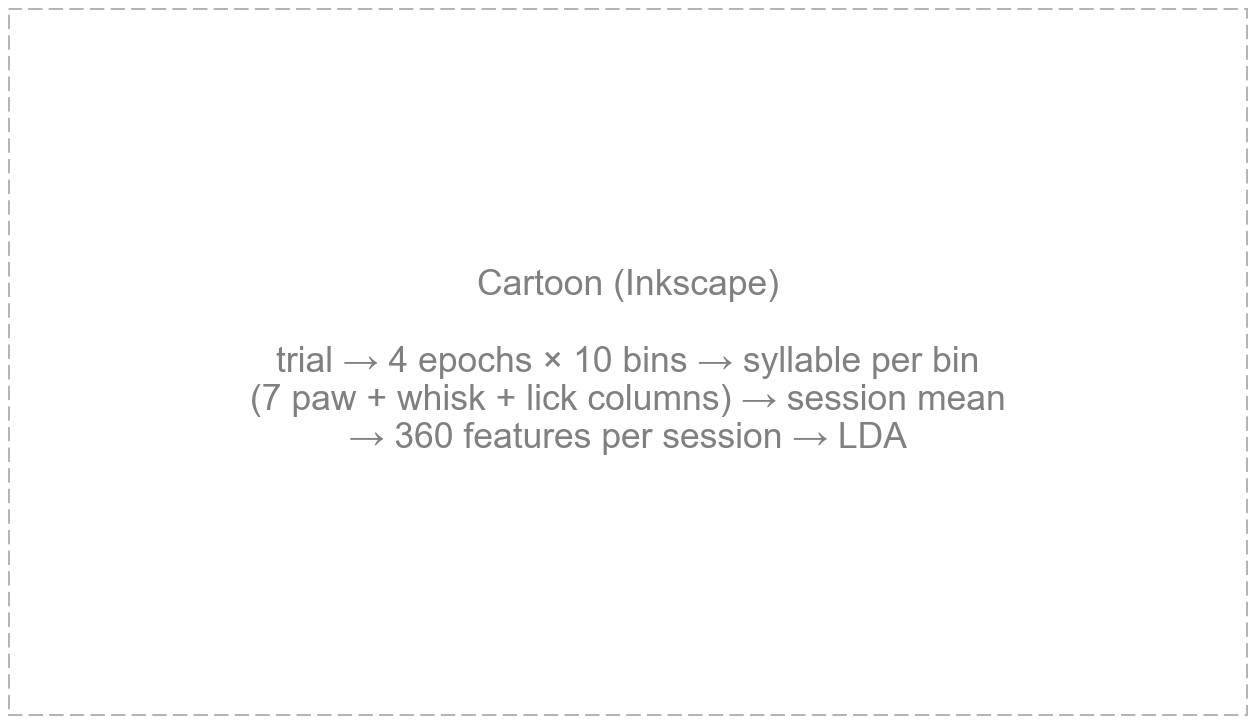

In [4]:
def draw_A(fig, spec):
    ax = fig.add_subplot(spec)
    ax.set_axis_off()
    if A_PLACEHOLDER:
        ax.add_patch(Rectangle((0, 0), 1, 1, transform=ax.transAxes, fill=False, ec='0.7', ls='--', lw=0.7))
        ax.text(0.5, 0.5, 'Cartoon (Inkscape)\n\ntrial → 4 epochs × 10 bins → syllable per bin\n'
                '(7 paw + whisk + lick columns) → session mean\n→ 360 features per session → LDA',
                ha='center', va='center', transform=ax.transAxes, fontsize=fs_small, color='0.5')
    return [ax]

fig = plt.figure(figsize=(4, 2.3)); draw_A(fig, fig.add_gridspec(1, 1)[0]); plt.show()

## Panel B — identification across sessions, mice and labs

`B_DESIGN = 'half'` (default): Figure 1A of `lda_shrinkage_figures`. Leave-one-session-out is the LDA's 56-way prediction (one point per repeat). In the half-split tests the LDA is fit on half of the mice, or on every mouse of half of the labs, and each held-out session is matched to the nearest held-out mouse centroid (~28-way, enrolment sessions drawn from that mouse's other sessions); points are the 50 splits. Mouse and lab splits are size-matched, so their difference is the cost of unseen labs.

`B_DESIGN = 'one_out'`: the 56-way leave-one-mouse/lab-out of the supplement. Mice that did not train the axes look alike in them, which favours an unseen mouse's own centroid against the 55 seen ones (the decoy test printed below), so these are biased upward.

Open markers: the same nearest-centroid identification on the 360 z-scored syllable features, no LDA.

Session out        LDA 0.865  syllable space 0.696  chance 0.018  (n = 1)
Half of mice out   LDA 0.815  syllable space 0.773  chance 0.036  (n = 50)
Half of labs out   LDA 0.810  syllable space 0.751  chance 0.036  (n = 50)


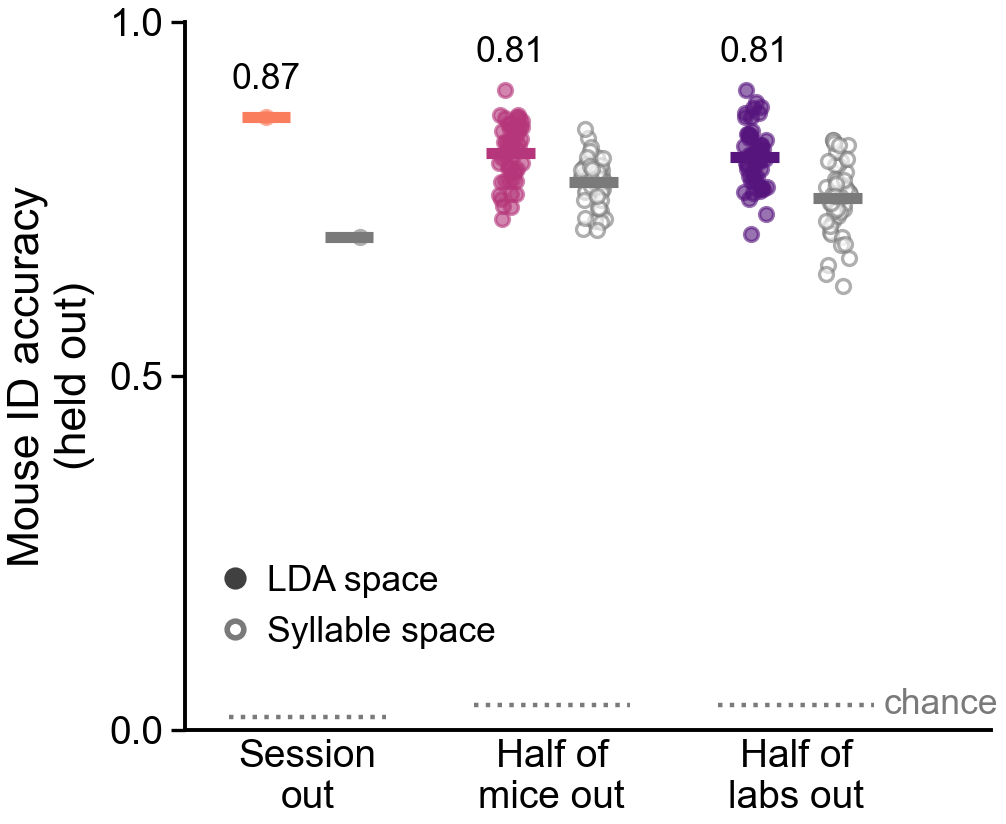

In [5]:
if B_DESIGN == 'one_out':
    B_TESTS = [('loso', 'Session\nout'), ('lomo', 'Mouse\nout'), ('lolo', 'Lab\nout')]
    B_RES = {k: {**RES['one_out'][k], 'chance': 1 / N_MICE} for k, _ in B_TESTS}
else:
    B_TESTS = [('loso', 'Session\nout'), ('mice', 'Half of\nmice out'), ('labs', 'Half of\nlabs out')]
    B_RES = {'loso': {**RES['one_out']['loso'], 'chance': 1 / N_MICE}, 'mice': RES['half']['mice'], 'labs': RES['half']['labs']}
for k, lbl in B_TESTS:
    r = B_RES[k]
    print(f"{lbl.replace(chr(10), ' '):18s} LDA {np.mean(r['lda']):.3f}  syllable space {np.mean(r['syllable']):.3f}  "
          f"chance {r['chance']:.3f}  (n = {np.size(r['lda'])})")
if B_DESIGN == 'one_out':
    print(f"decoy: an unseen mouse is picked {RES['decoy']:.3f} of the time vs chance {RES['decoy_chance']:.3f} "
          f"({RES['decoy'] / RES['decoy_chance']:.1f}x)")

def draw_B(fig, spec, legend=True):
    ax = fig.add_subplot(spec)
    jit = np.random.default_rng(1)
    spaces = [('lda', -0.17), ('syllable', 0.17)] if B_SYLLABLE_SPACE else [('lda', 0)]
    for xi, (key, _) in enumerate(B_TESTS):
        res = B_RES[key]
        for name, dx in spaces:
            ec, fc = (TEST_COLOR[key], TEST_COLOR[key]) if name == 'lda' else (ps.NEUTRAL, 'white')
            v = np.atleast_1d(res[name])
            ax.plot(xi + dx + jit.uniform(-0.05, 0.05, len(v)), v, 'o', ms=2.5, alpha=0.6, mec=ec, mfc=fc,
                    mew=0.6, zorder=3)
            ax.hlines(v.mean(), xi + dx - 0.1, xi + dx + 0.1, color=ec, lw=2, zorder=4)
        ax.text(xi + spaces[0][1], np.max(res['lda']) + 0.03, f"{np.mean(res['lda']):.2f}", ha='center',
                va='bottom', fontsize=fs_small)
        ax.hlines(res['chance'], xi - 0.32, xi + 0.32, color=ps.NEUTRAL, ls=':', lw=0.8)
    ax.text(len(B_TESTS) - 1 + 0.36, B_RES[B_TESTS[-1][0]]['chance'], 'chance', ha='left', va='center',
            color=ps.NEUTRAL, fontsize=fs_small)
    ax.set_xticks(range(len(B_TESTS)))
    ax.set_xticklabels([lbl for _, lbl in B_TESTS])
    ax.tick_params(axis='x', length=0)
    ax.set_xlim(-0.5, len(B_TESTS) - 0.2)
    ax.set_ylim(0, 1); ax.set_yticks([0, 0.5, 1])
    ax.set_ylabel('Mouse ID accuracy' + (f'\n({N_MICE}-way)' if B_DESIGN == 'one_out' else '\n(held out)'))
    if legend and B_SYLLABLE_SPACE:
        ax.legend(handles=[Line2D([], [], marker='o', ls='', mec='0.25', mfc='0.25', ms=3, label='LDA space'),
                           Line2D([], [], marker='o', ls='', mec=ps.NEUTRAL, mfc='white', ms=3, label='Syllable space')],
                  loc='lower left', bbox_to_anchor=(0.0, 0.08), frameon=False, fontsize=fs_small, handletextpad=0.2)
    return [ax]

fig = plt.figure(figsize=(2.6, 2.3)); draw_B(fig, fig.add_gridspec(1, 1)[0]); plt.show()

## Panel C — how many discriminants carry individuality?

Leave-one-session-out. For component k, $R^2_k = 1 - \sum (z_k - \mu_{\text{own},k})^2 / \sum (z_k - \bar\mu_k)^2$ over held-out sessions: how much of a new session's position on that axis its mouse predicts (an out-of-sample repeatability; negative where the training centroid predicts worse than the grand mean). Coloured band: 95% bootstrap over held-out sessions; grey band: the same for axes fit to shuffled mouse labels. The dotted line marks the last component, counted from LD1, whose band clears the shuffled one.

7 of 55 discriminants above the shuffled band; R^2 LD1-3: [0.711 0.678 0.726]


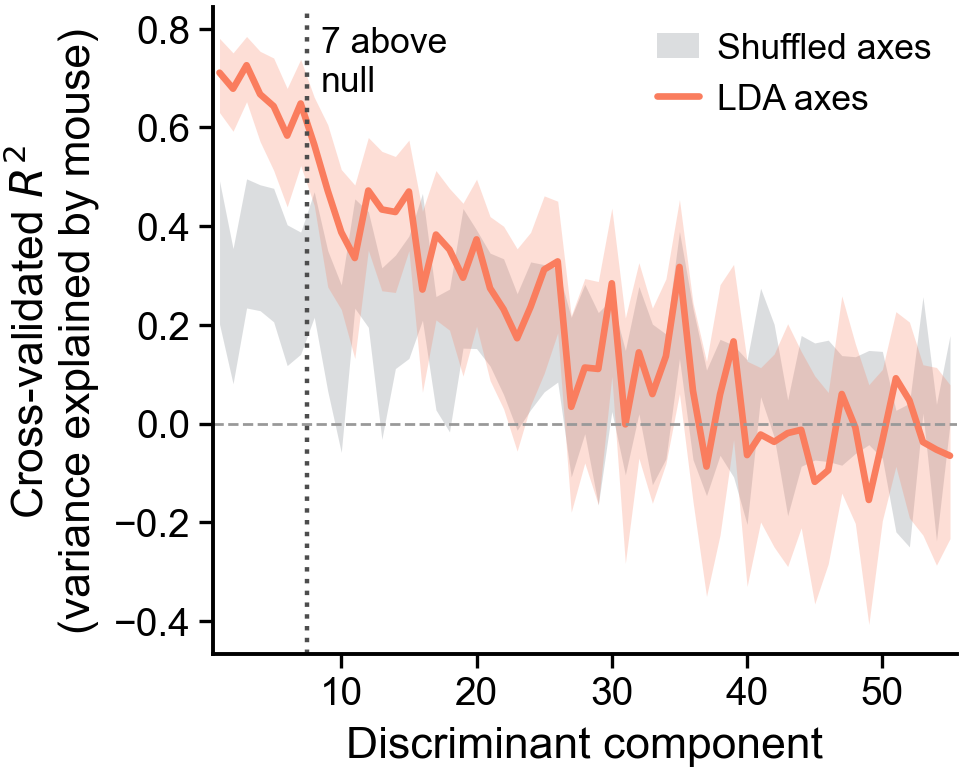

In [6]:
R2 = RES['r2']
K = len(R2['r2'])
N_SIG = R2['n_sig']
print(f'{N_SIG} of {K} discriminants above the shuffled band; R^2 LD1-3: {np.round(R2["r2"][:3], 3)}')

def draw_C(fig, spec, legend=True):
    ax = fig.add_subplot(spec)
    kk = np.arange(1, K + 1)
    ax.fill_between(kk, R2['shuf_lo'], R2['shuf_hi'], color=ps.NULL_BAND, alpha=0.35, lw=0, label='Shuffled axes')
    ax.fill_between(kk, R2['true_lo'], R2['true_hi'], color=TEST_COLOR['loso'], alpha=0.25, lw=0)
    ax.plot(kk, R2['r2'], color=TEST_COLOR['loso'], label='LDA axes')
    ax.axhline(0, color='0.6', ls='--', lw=0.5)
    ax.axvline(N_SIG + 0.5, color='0.3', ls=':', lw=0.8)
    ax.text(N_SIG + 1.5, 0.97, f'{N_SIG} above\nnull', transform=ax.get_xaxis_transform(), fontsize=fs_small, va='top')
    ax.set_xlim(0.5, K + 0.5)
    ax.set_xlabel('Discriminant component')
    ax.set_ylabel('Cross-validated $R^2$\n(variance explained by mouse)')
    if legend:
        ax.legend(frameon=False, fontsize=fs_small, loc='upper right', handlelength=1.2)
    return [ax]

fig = plt.figure(figsize=(2.4, 2.1)); draw_C(fig, fig.add_gridspec(1, 1)[0]); plt.show()

## Panel D — identification in the first k dimensions

Nearest centroid using only the first k discriminants: leave-one-session-out and the two half-split tests (which stop at 25 dimensions: their training half has ≥ 26 mice), against the first k principal components (label-blind, leave-one-session-out). Dots: smallest k reaching 90% of the curve's maximum. Chance is below 0.04 for every curve. Same three tests as B.

Session out       LD1 alone 0.08, 5 dims 0.55, 10 dims 0.70, 90% of max at k = 15
Half of mice out  LD1 alone 0.12, 5 dims 0.53, 10 dims 0.70, 90% of max at k = 12
Half of labs out  LD1 alone 0.12, 5 dims 0.50, 10 dims 0.69, 90% of max at k = 13
PCA               5 dims 0.39, 10 dims 0.58, max 0.71


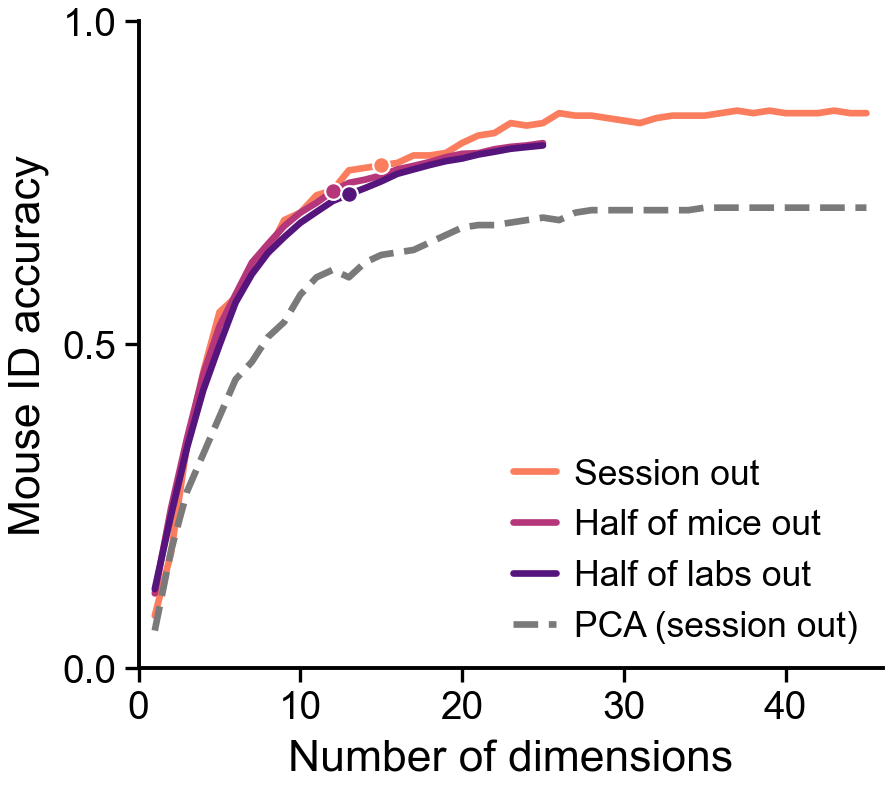

In [7]:
CURVES = RES['curves']

def k_at(curve, frac=0.9):
    c = curve[~np.isnan(curve)]
    return int(np.argmax(c >= frac * c.max())) + 1

D_LINES = [('loso', 'Session out'), ('mice', 'Half of mice out'), ('labs', 'Half of labs out')]
for key, lbl in D_LINES:
    c = CURVES[key]
    print(f'{lbl:17s} LD1 alone {c[0]:.2f}, 5 dims {c[4]:.2f}, 10 dims {c[9]:.2f}, 90% of max at k = {k_at(c)}')
print(f"{'PCA':17s} 5 dims {CURVES['pca'][4]:.2f}, 10 dims {CURVES['pca'][9]:.2f}, max {np.nanmax(CURVES['pca']):.2f}")

def draw_D(fig, spec, legend=True):
    ax = fig.add_subplot(spec)
    dims = np.arange(1, MAX_DIMS_PLOT + 1)
    for key, lbl in D_LINES:
        c = CURVES[key][:MAX_DIMS_PLOT]
        ax.plot(dims[:len(c)], c, color=TEST_COLOR[key], label=lbl)
        k90 = k_at(CURVES[key])
        ax.plot(k90, c[k90 - 1], 'o', ms=3, color=TEST_COLOR[key], mec='white', mew=0.4, zorder=4)
    ax.plot(dims, CURVES['pca'][:MAX_DIMS_PLOT], color=ps.NEUTRAL, ls='--', label='PCA (session out)')
    ax.set_xlim(0, MAX_DIMS_PLOT + 1)
    ax.set_ylim(0, 1); ax.set_yticks([0, 0.5, 1])
    ax.set_xlabel('Number of dimensions')
    ax.set_ylabel('Mouse ID accuracy')
    if legend:
        ax.legend(frameon=False, fontsize=fs_small, loc='lower right', handlelength=1.2)
    return [ax]

fig = plt.figure(figsize=(2.4, 2.1)); draw_D(fig, fig.add_gridspec(1, 1)[0]); plt.show()

## Panel E — own mouse, labmates, other labs

Leave-one-session-out, all discriminants: the distance from each held-out session to every mouse centroid (the LDA space is within-mouse whitened, so this is a within-mouse Mahalanobis distance), split by whether the centroid is its own mouse, a labmate or a mouse from another lab. Gaussian KDE.

Own mouse   median 11.73  (n = 260)
Labmates    median 22.82  (n = 1358)
Other labs  median 24.44  (n = 12942)


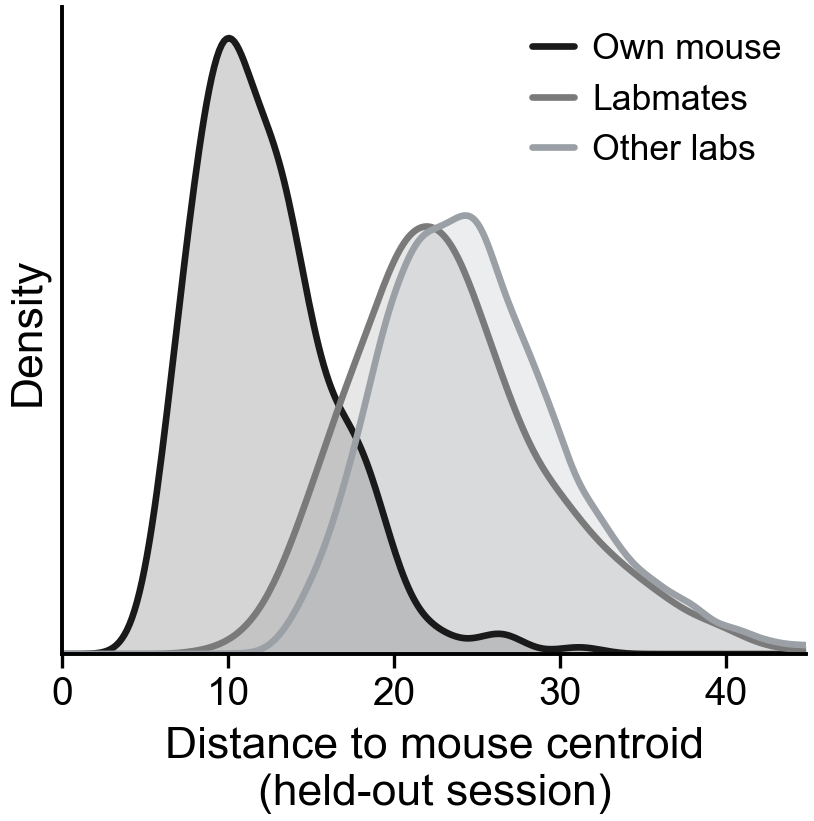

In [8]:
DIST = RES['dist_groups']
for k, v in DIST.items():
    print(f'{k:11s} median {np.median(v):.2f}  (n = {len(v)})')

def draw_E(fig, spec, legend=True):
    ax = fig.add_subplot(spec)
    grid = np.linspace(0, np.percentile(np.concatenate(list(DIST.values())), 99.5), 300)
    for (name, v), col in zip(DIST.items(), ['0.1', ps.NEUTRAL, ps.NULL_BAND]):
        dens = gaussian_kde(v)(grid)
        ax.fill_between(grid, dens, color=col, alpha=0.18, lw=0)
        ax.plot(grid, dens, color=col, label=name)
    ax.set_xlim(0, grid[-1])
    ax.set_ylim(bottom=0)
    ax.set_yticks([])
    ax.set_xlabel('Distance to mouse centroid\n(held-out session)')
    ax.set_ylabel('Density')
    if legend:
        ax.legend(frameon=False, fontsize=fs_small, loc='upper right', handlelength=1.2)
    return [ax]

fig = plt.figure(figsize=(2.4, 2.1)); draw_E(fig, fig.add_gridspec(1, 1)[0]); plt.show()

## Panel F — what segmenting into syllables keeps and loses

From `segmentation_vs_raw_figures.ipynb`: per channel, the syllables (filled) against the raw signal they are built from, per-session z-scored and never more dimensions than the syllables (open). Paw: paw syllables (280) vs speed per paw (80). Whisk: whisking states vs whisker motion energy, lick: licking states vs lick count (40 each, the whisk + lick block split by column). All: the 360 LDA features vs speed per paw + whisker ME + lick count (160).

* **Mouse ID**: leave-one-session-out, shrinkage LDA, ≤ 3 sessions per mouse.
* **Lab ID from a held-out mouse**: every session of the test mouse left out — lab signal that generalises across animals.

Error bars: 95% CIs, 2,000 bootstrap resamples of mice. Dotted: chance (1/56, 1/10).

syllables: 8_k_10_bin_syllables_02-10-2026
NOT YET IN ci_segmentation_vs_raw.csv: ['whisk', 'lick'] -- rerun vigor/zscore/ci_segmentation_vs_raw.py. Drawn without them.
metric              mouse  lab_lomo
channel kind                       
paw     syllables   0.728     0.215
        raw         0.783     0.446
        difference -0.055    -0.231
all     syllables   0.850     0.358
        raw         0.894     0.577
        difference -0.044    -0.219


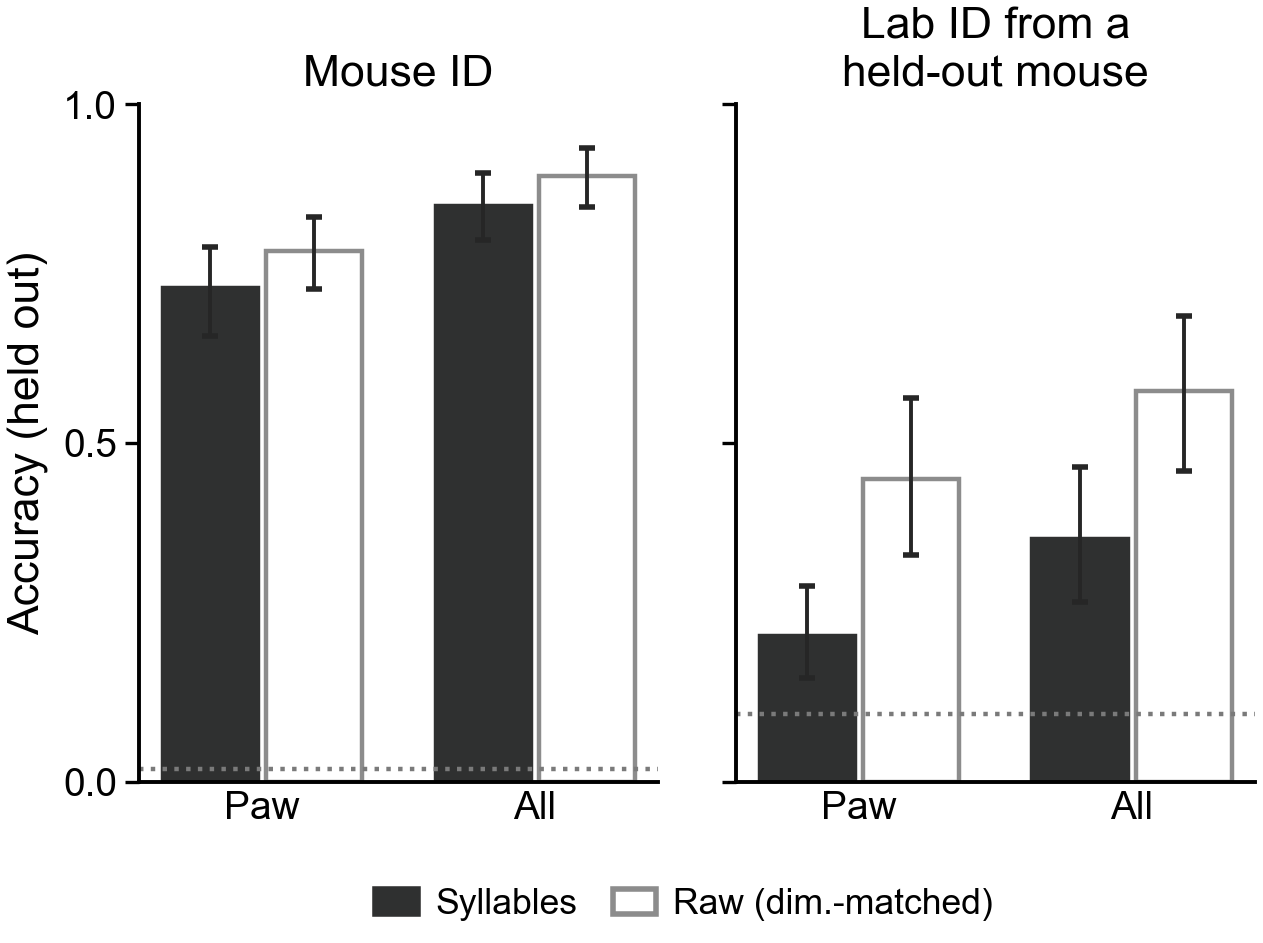

In [9]:
SEG = pd.read_csv(SEG_VS_RAW)
SEG['kind'] = np.where(SEG['rep'] == 'syllables', 'syllables',
                       np.where(SEG['rep'].str.startswith('difference'), 'difference', 'raw'))
print('syllables:', ', '.join(SEG['syllable_file'].unique()))
_missing = [c for c in F_CHANNELS if c not in set(SEG['channel'])]
if _missing:
    print(f'NOT YET IN {SEG_VS_RAW.name}: {_missing} -- rerun vigor/zscore/ci_segmentation_vs_raw.py. Drawn without them.')
F_CH = [c for c in F_CHANNELS if c not in _missing]
CH_LABEL = {'paw': 'Paw', 'whisk': 'Whisk', 'lick': 'Lick', 'whisk + lick': 'Whisk\n+ lick', 'all': 'All'}
F_CHANCE = {'mouse': 1 / N_MICE, 'mouse_lab': 1 / N_MICE, 'lab_lomo': 1 / N_LABS}
SYL_INK, RAW_INK = '#2F3030', '#8C8C8C'
print(SEG[SEG['channel'].isin(F_CH) & SEG['metric'].isin([m for m, _ in F_METRICS])]
      .pivot_table(index=['channel', 'kind'], columns='metric', values='estimate', sort=False).round(3))

def draw_F(fig, spec, legend=True):
    g = spec.subgridspec(1, len(F_METRICS), wspace=0.15)
    axes, w = [], 0.38
    for j, (m, title) in enumerate(F_METRICS):
        ax = fig.add_subplot(g[j], sharey=axes[0] if axes else None); axes.append(ax)
        for i, ch in enumerate(F_CH):
            for off, kind, face, edge in [(-w / 2, 'syllables', SYL_INK, SYL_INK), (w / 2, 'raw', 'white', RAW_INK)]:
                r = SEG[(SEG['channel'] == ch) & (SEG['metric'] == m) & (SEG['kind'] == kind)].iloc[0]
                ax.bar(i + off, r['estimate'], width=w * 0.92, color=face, edgecolor=edge, lw=0.8)
                ax.errorbar(i + off, r['estimate'], yerr=[[r['estimate'] - r['lo']], [r['hi'] - r['estimate']]],
                            color='0.15', lw=0.7, capsize=1.5)
        ax.axhline(F_CHANCE[m], color=ps.NEUTRAL, ls=':', lw=0.8)
        ax.set_title(title, fontsize=plt.rcParams['font.size'])
        ax.set_xticks(range(len(F_CH)))
        ax.set_xticklabels([CH_LABEL[c] for c in F_CH])
        ax.tick_params(axis='x', length=0)
        if j:
            ax.tick_params(labelleft=False)
    axes[0].set_ylim(0, 1); axes[0].set_yticks([0, 0.5, 1])
    axes[0].set_ylabel('Accuracy (held out)')
    if legend:
        axes[0].legend(handles=[Patch(facecolor=SYL_INK, edgecolor=SYL_INK, label='Syllables'),
                                Patch(facecolor='white', edgecolor=RAW_INK, label='Raw (dim.-matched)')],
                       ncol=2, loc='upper center', bbox_to_anchor=(1.05, -0.12), frameon=False, fontsize=fs_small,
                       handlelength=1.2, columnspacing=1.0)
    return axes

fig = plt.figure(figsize=(3.6, 2.2)); draw_F(fig, fig.add_gridspec(1, 1)[0]); plt.show()

## Panel G — are the individual axes stable?

The **reference** is the saved embedding (all 260 sessions, every mouse counted once in the between-mouse scatter, shrinkage 0.5). It is refit after dropping 20% of each mouse's sessions (100 refits), one mouse (56) or one lab (10), and all sessions are projected through both. Per discriminant k:

* **Single axis**: |Pearson r|, across the 260 sessions, between reference LDk and refit LDk. Sign-free, because an eigenvector's sign is arbitrary. So yes, a correlation.
* **Top-k subspace**: how much of the reference's first-k space the refit's first-k space reproduces, as the mean squared canonical correlation (1 = the same subspace). Rank swaps between near-tied axes lower the single-axis agreement but not this.

**Lines and bands.** The line is the median over refits. The refits are a sensitivity analysis, not repeated measurements, so the bands are not error bars around a mean; each scheme gets the summary that fits it (`G_BAND = 'standard'`):

* **Drop 20% of sessions** is a resampling scheme (100 random refits): band = 95% of refits (2.5th–97.5th percentile).
* **Drop one mouse / one lab** are leave-one-out influence checks (56 and 10 refits) — the question is whether any single mouse or lab drives the axis, so band = full range (worst to best refit). Percentiles of 10 lab refits would mean little.

In `lda_shrinkage_figures` every band runs from the median down to the worst refit (`G_BAND = 'worst'`); for the session refits that is one outlier (single-axis LD1 0.10 against a median of 0.95, while its best match never falls below 0.75 — a rank swap with a near-tied axis, not a lost axis). Rank swaps can still pull the single-axis band down for the higher discriminants; the top-k subspace measure is immune to them, which is why both are shown. Dotted line: the discriminants above the shuffled R² null (panel C).

sessions (100 refits) single axis median LD1: 0.95  LD2: 0.89  LD3: 0.58  LD5: 0.81  LD10: 0.55 | top-10 subspace 0.91
mouse    ( 56 refits) single axis median LD1: 1.00  LD2: 0.99  LD3: 0.99  LD5: 0.99  LD10: 0.97 | top-10 subspace 0.99
lab      ( 10 refits) single axis median LD1: 0.98  LD2: 0.95  LD3: 0.82  LD5: 0.82  LD10: 0.56 | top-10 subspace 0.94


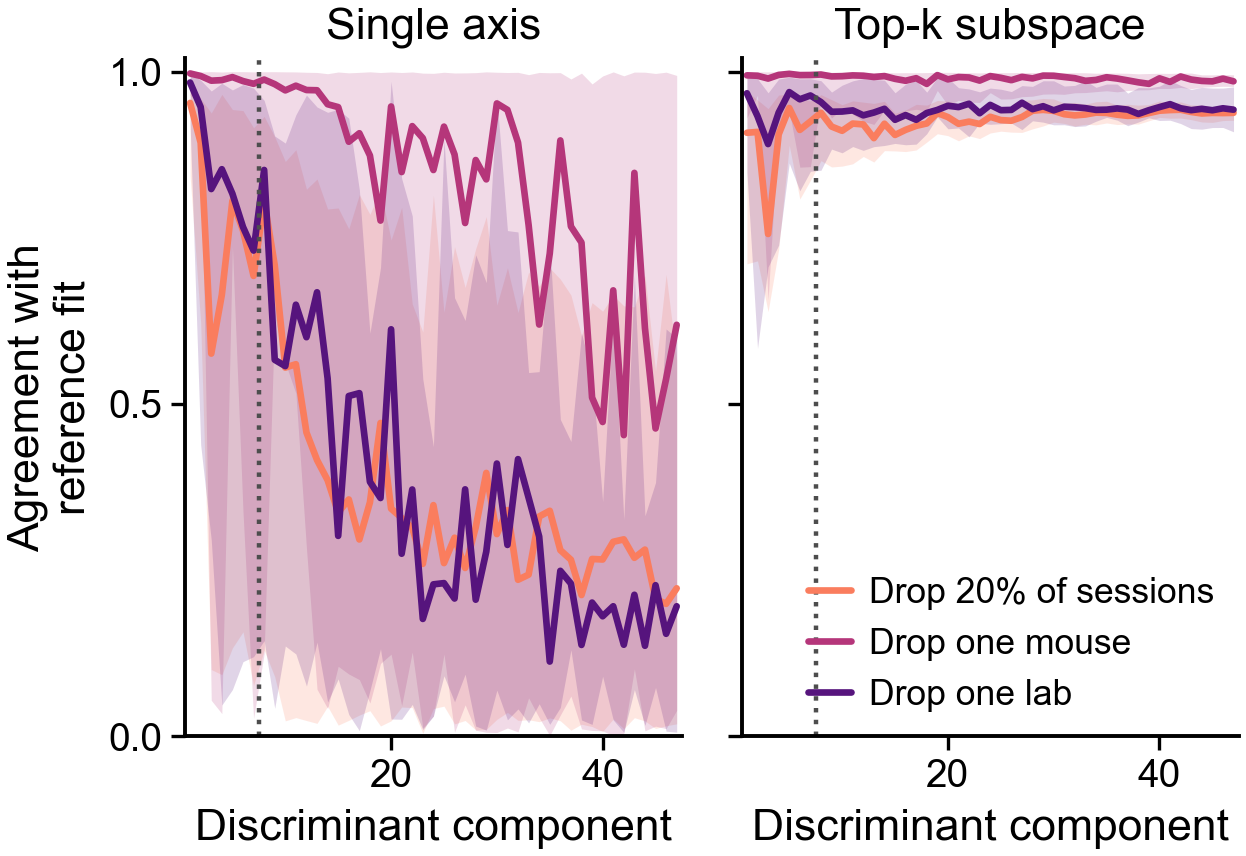

In [10]:
STAB, K_STAB = RES['stability']['stab'], RES['stability']['k']
N_REFITS = RES['stability']['n_refits']
SCHEME_STYLE = {'sessions': ('Drop 20% of sessions', TEST_COLOR['loso']),
                'mouse': ('Drop one mouse', TEST_COLOR['mice']),
                'lab': ('Drop one lab', TEST_COLOR['labs'])}
for s_ in SCHEME_STYLE:
    print(f'{s_:8s} ({N_REFITS[s_]:3d} refits) single axis median ' + '  '.join(
        f'LD{k_}: {np.median(STAB[s_]["same axis"][:, k_ - 1]):.2f}' for k_ in (1, 2, 3, 5, 10))
        + f' | top-10 subspace {np.median(STAB[s_]["subspace"][:, 9]):.2f}')

def g_band(a, scheme):
    if G_BAND == 'standard':
        if scheme == 'sessions':                       # resampling: 95% of refits
            return np.percentile(a, 2.5, axis=0), np.percentile(a, 97.5, axis=0)
        return a.min(axis=0), a.max(axis=0)            # leave-one-out: full range
    if G_BAND == 'iqr':
        return np.percentile(a, 25, axis=0), np.percentile(a, 75, axis=0)
    return a.min(axis=0), np.median(a, axis=0)

def draw_G(fig, spec, legend=True):
    g = spec.subgridspec(1, len(G_METRICS), wspace=0.12)
    axes, kk = [], np.arange(1, K_STAB + 1)
    for j, (metric, title) in enumerate(G_METRICS):
        ax = fig.add_subplot(g[j], sharey=axes[0] if axes else None); axes.append(ax)
        for s_, (label, col) in SCHEME_STYLE.items():
            a = STAB[s_][metric][:, :K_STAB]
            ax.fill_between(kk, *g_band(a, s_), color=col, alpha=0.18, lw=0)
            ax.plot(kk, np.median(a, axis=0), color=col, label=label)
        ax.axvline(N_SIG + 0.5, color='0.3', ls=':', lw=0.8)
        ax.set_title(title, fontsize=plt.rcParams['font.size'])
        ax.set_xlabel('Discriminant component')
        ax.set_xlim(0.5, K_STAB + 0.5)
        if j:
            ax.tick_params(labelleft=False)
    axes[0].set_ylim(0, 1.02); axes[0].set_yticks([0, 0.5, 1])
    axes[0].set_ylabel('Agreement with\nreference fit')
    if legend:
        axes[-1].legend(frameon=False, fontsize=fs_small, loc='lower right', handlelength=1.2)   # the subspace plot's empty lower half
    return axes

fig = plt.figure(figsize=(3.4, 2.2)); draw_G(fig, fig.add_gridspec(1, 1)[0]); plt.show()

## The assembled figure

180 mm wide, same type size everywhere (drawn by the `draw_*` functions above, nothing rescaled). Top row: A (cartoon space) and B. Middle: C, D, E. Bottom: F (two metrics) and G (two measures). Writes `figure_generation/figures/fig_lda.pdf` (for LaTeX; undated so the `\includegraphics` line never changes) and a dated SVG. Set `A_PLACEHOLDER = False` for the SVG that goes to Inkscape.

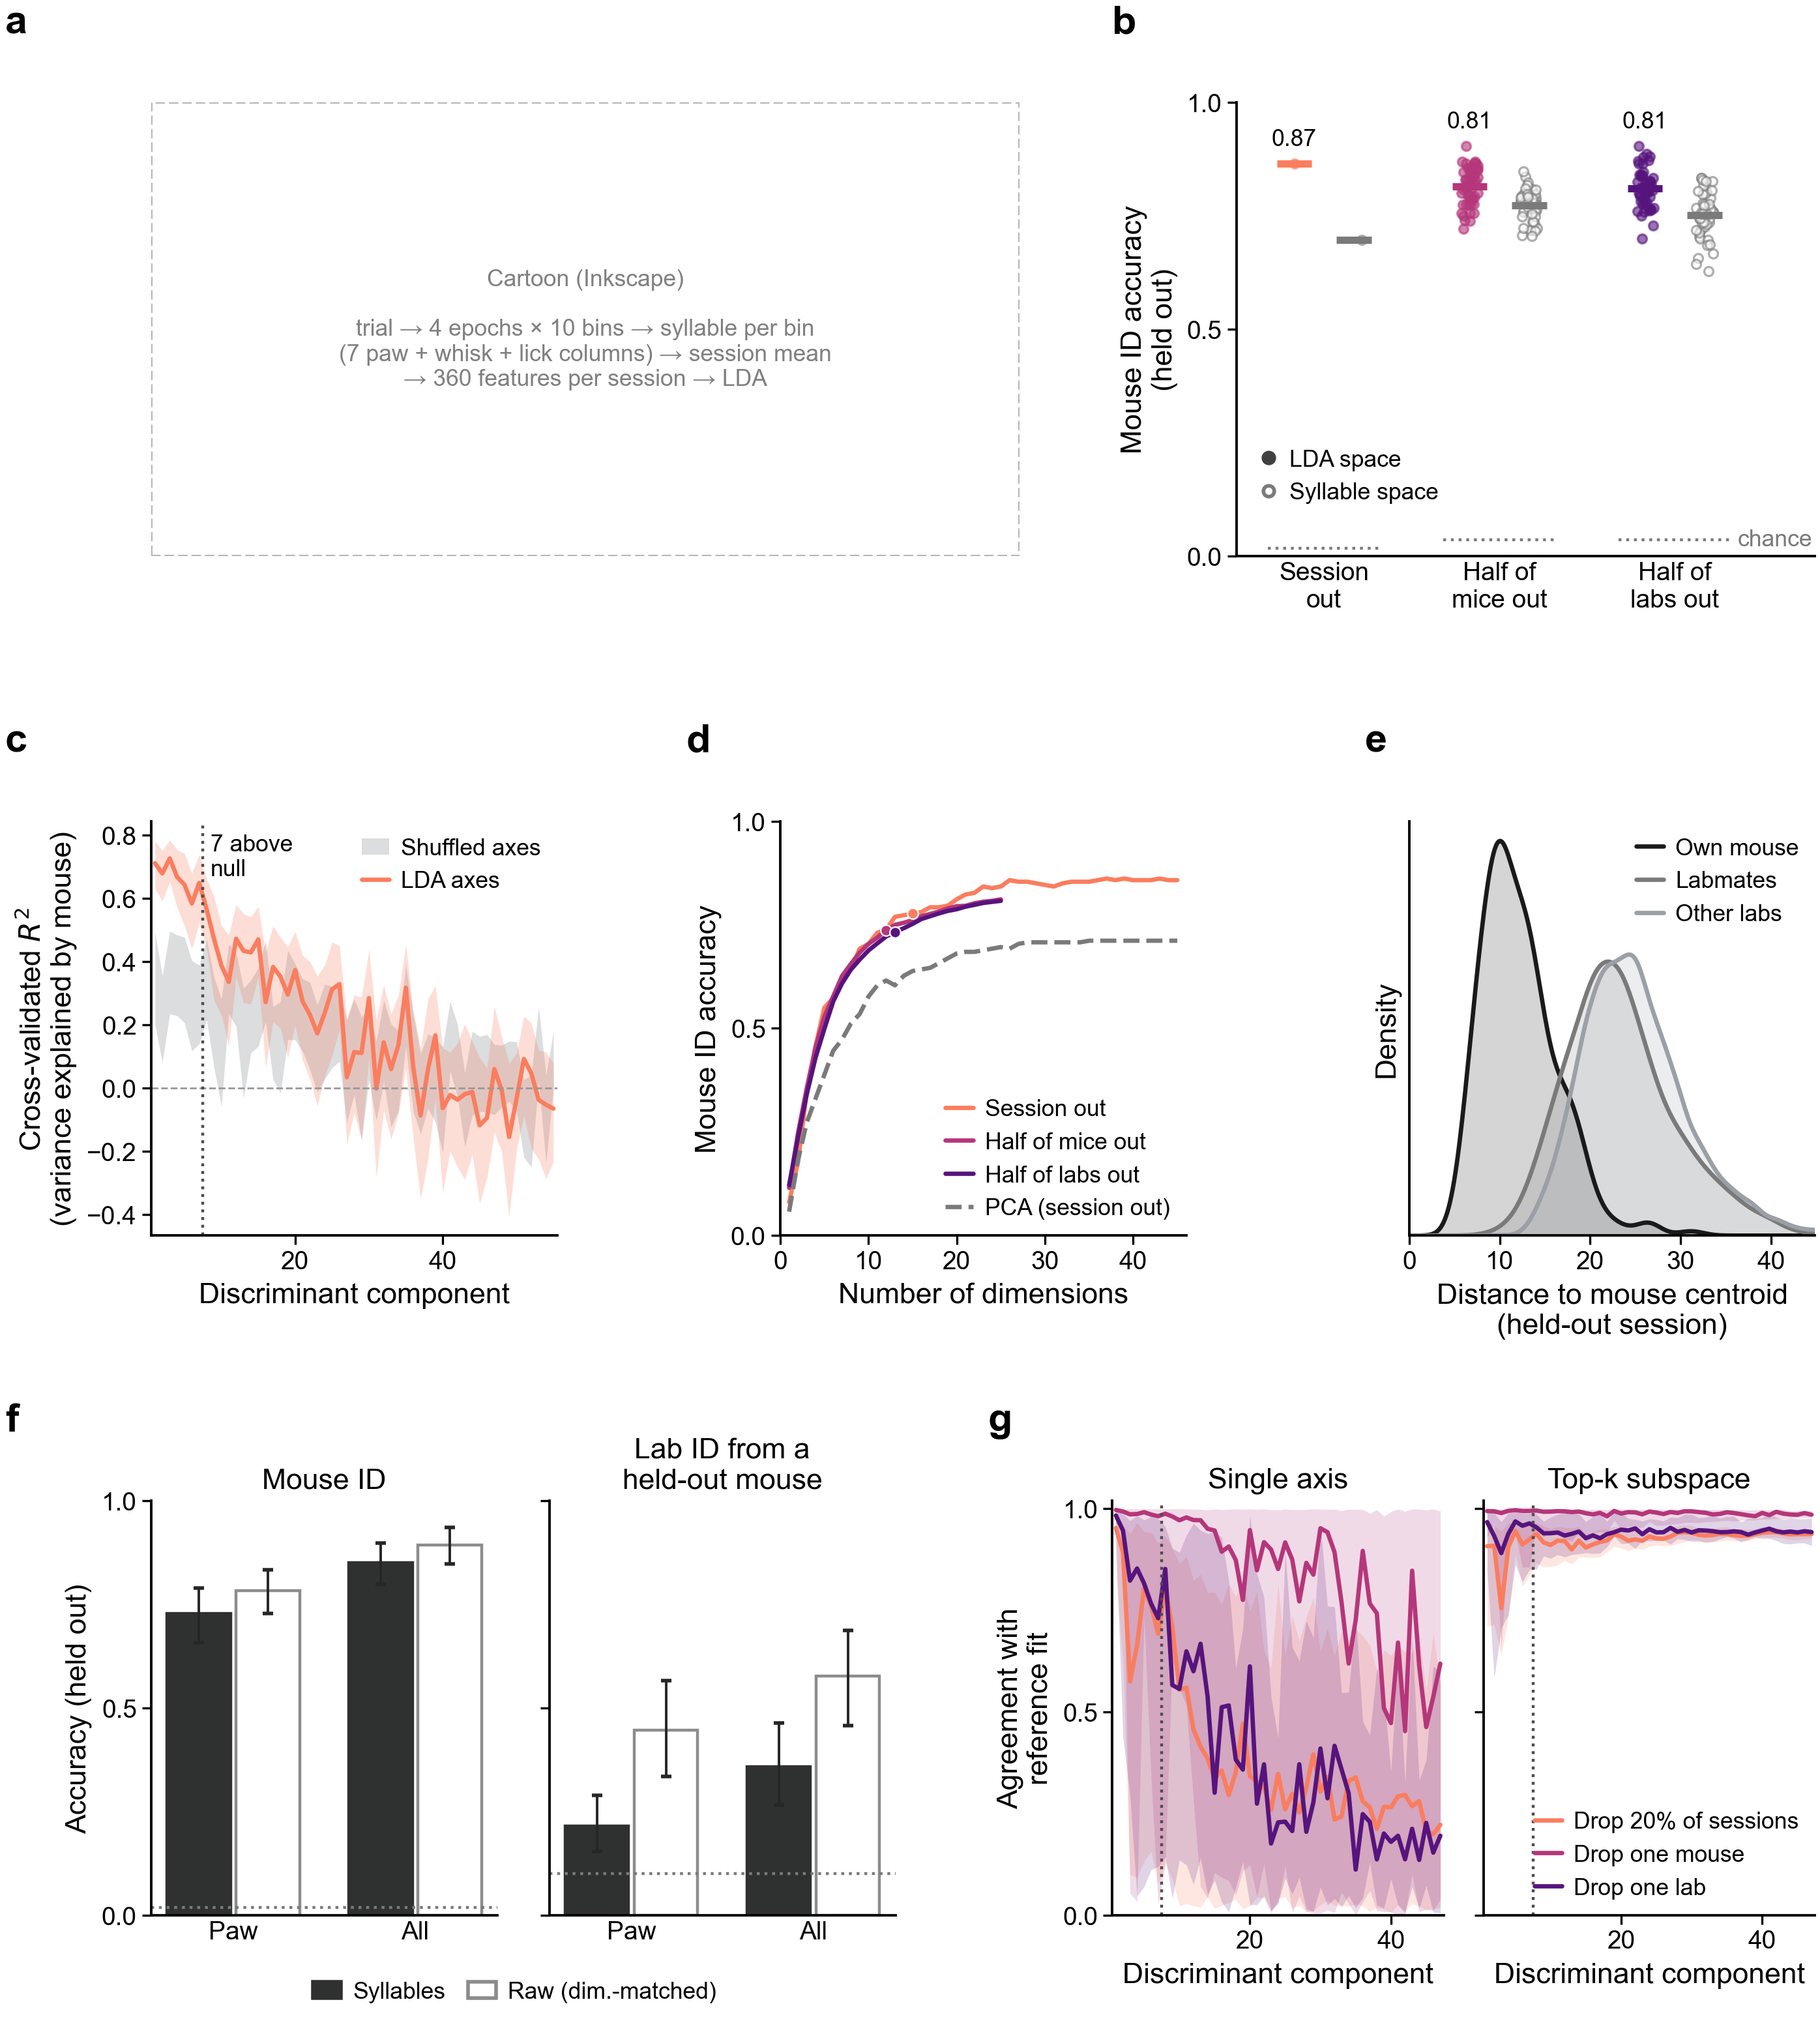

wrote figure_generation/figures/fig_lda_08-10-2026.svg


wrote figure_generation/figures/fig_lda.pdf


In [11]:
from datetime import date
LETTERS = {k: k.lower() for k in 'ABCDEFG'}
FIG_W, FIG_H = 7.09, 7.9

def letter(fig, axes, key, x=None, y=None, dy=0.012):
    if x is None:
        x = max(min(a.get_tightbbox(fig.canvas.get_renderer()).transformed(fig.transFigure.inverted()).x0
                    for a in axes) - 0.005, 0.003)
    if y is None:
        y = max(a.get_position().y1 for a in axes) + dy
    fig.text(x, y, LETTERS[key], fontsize=plt.rcParams['font.size'] + 3, fontweight='bold', ha='left', va='bottom')

fig = plt.figure(figsize=(FIG_W, FIG_H))
outer = fig.add_gridspec(3, 1, height_ratios=[2.3, 2.1, 2.1], hspace=0.62, left=0.085, right=0.985, top=0.96, bottom=0.08)
row1 = outer[0].subgridspec(1, 2, width_ratios=[4.2, 2.8], wspace=0.3)
row2 = outer[1].subgridspec(1, 3, wspace=0.55)
row3 = outer[2].subgridspec(1, 2, width_ratios=[3.6, 3.4], wspace=0.3)
panels = {'A': draw_A(fig, row1[0]), 'B': draw_B(fig, row1[1]),
          'C': draw_C(fig, row2[0]), 'D': draw_D(fig, row2[1]), 'E': draw_E(fig, row2[2]),
          'F': draw_F(fig, row3[0]), 'G': draw_G(fig, row3[1])}

# left column (c, f): one left edge for the axes; a's box starts there too
LEFT = ['C', 'F']
x_left = max(panels[k][0].get_position().x0 for k in LEFT)
for k in LEFT + ['A']:
    b = panels[k][0].get_position()
    panels[k][0].set_position([x_left, b.y0, b.x1 - x_left, b.height])
fig.canvas.draw()
r_ = fig.canvas.get_renderer()
x_letter = max(min(panels[k][0].get_tightbbox(r_).transformed(fig.transFigure.inverted()).x0 for k in LEFT) - 0.005, 0.003)
# letters of one row share one y
top = lambda keys: max(a.get_position().y1 for k in keys for a in panels[k]) + 0.03
ROW_Y = {k: top(row) for row in ('AB', 'CDE', 'FG') for k in row}
for k, axes in panels.items():
    letter(fig, axes, k, x=x_letter if k in LEFT + ['A'] else None, y=ROW_Y[k])
plt.show()

OUT_DIR = PI / 'figure_generation' / 'figures'
OUT_DIR.mkdir(exist_ok=True)
for path in [OUT_DIR / f"{FIG}_{date.today().strftime('%d-%m-%Y')}.svg", OUT_DIR / f'{FIG}.pdf']:
    fig.savefig(path)
    print('wrote', path.relative_to(PI))